In [9]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

import sys

from pathlib import Path
nb_dir = Path.cwd()
help_func_path = os.path.join(nb_dir,'helper_code')

sys.path.append(help_func_path) 

from plotting_functions import scatter_helper, plot_3d_scatters
from saving_functions import save_dataset

In [10]:
# generate a list of random seeds to use for saving data

# rng = np.random.default_rng(42)
# num_seeds = 10
# random_seeds_lst = rng.integers(0, 2**20, size=num_seeds).tolist()

random_seeds_lst = [42,980]

In [11]:
def isotropic_gaussian(n_samples, n_features,scale=1, random_state=None):
    rng = np.random.default_rng(seed=random_state)
    return scale*rng.standard_normal((n_samples, n_features))

In [12]:
n_samples = 300
n_features = 5
scale_param = 2.5

X = isotropic_gaussian(n_samples, n_features,scale=scale_param, random_state=0)


In [13]:
X[:, 0].shape, X[:, 1].shape

((300,), (300,))

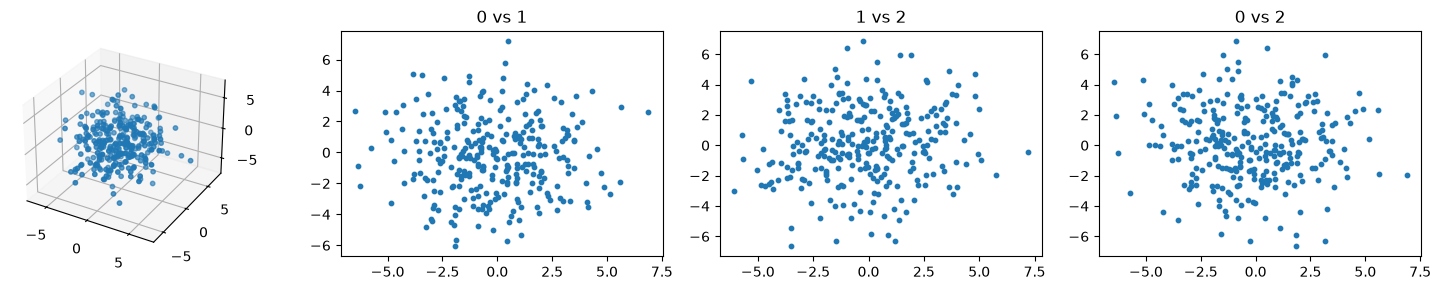

In [14]:
plot_3d_scatters(X,'',y=None)

In [15]:
from itertools import product

In [18]:
dataset_type = 'spherical_gaussian_cloud'

# n_samples_lst = [1000,5000,10000]
# n_features_lst = [3,10,100,1000,5000]

n_samples_lst = [1000,10000]
n_features_lst = [10,100,1000]
scale_param = 29.0

for n_samples, n_features in product(n_samples_lst, n_features_lst):
    
    X = isotropic_gaussian(n_samples, n_features,scale=scale_param, random_state=0)
    print(n_samples, n_features, X.shape)

    for sample_num,seed in enumerate(random_seeds_lst):
        
        print(n_features,seed)
        
        X = isotropic_gaussian(n_samples,n_features,seed)
        params_dict = {
            # 'N' : n_samples,
            # 'P' : n_features
            # 'seed' : seed
            'scale' : scale_param,
        }
        
        try:
            save_dataset(X, 
                        generator='isotropic_gaussian',
                        params=params_dict,
                        seed=seed,
                        category=['density'],
                        root='../all_data/')

        except:
            print('file already exists')

1000 10 (1000, 10)
10 42
10 980
1000 100 (1000, 100)
100 42
100 980
1000 1000 (1000, 1000)
1000 42
1000 980
10000 10 (10000, 10)
10 42
10 980
10000 100 (10000, 100)
100 42
100 980
10000 1000 (10000, 1000)
1000 42
1000 980
